<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>From Scratch MLP - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**

https://archive.ics.uci.edu/dataset/222/bank+marketing

---

# Initialise Notebook

In [2]:
# Install Requirements Using Pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [3]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Pycountry 
import pycountry

# GeoPy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# IPython Display 
from IPython.display import HTML

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [4]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [5]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

### Check for Internet Access

In [6]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [7]:
internet_required = False

In [8]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load and Explore the Dataset

From: https://archive.ics.uci.edu/dataset/222/bank+marketing

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed. 

[This dataset is] bank-full.csv with all examples and 17 inputs, ordered by date (older version of this dataset with less inputs). 

The classification goal is to predict if the client will subscribe (yes/no) a term deposit (variable y).

|Variable Name	|Role	|Type	|Demographic|	Description|	Units|	Missing Values|
|---|---|---|---|---|---|---|
|age|	Feature|	Integer|	Age|	|	|	no|
|job|	Feature	|Categorical	|Occupation	|type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')||		no|
|marital	|Feature|	Categorical|	Marital Status|	marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)||		no|
|education	|Feature|	Categorical	|Education Level|	(categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')||		no|
|default	|Feature|	Binary		||has credit in default?||		no|
|balance	|Feature|	Integer		||average yearly balance|	euros	|no|
|housing	|Feature|	Binary		||has housing loan?||		no|
|loan	|Feature|	Binary	||	has personal loan?||		no|
|contact	|Feature|	Categorical	||	contact communication type (categorical: 'cellular','telephone')||		yes|
|day	|Feature|	Integer	||	last contact day of the month||		unknown|
|month	|Feature|	Date	||	last contact month of the year||		unknown|
|duration	|Feature|	Integer	||	last contact duration, in seconds (numeric)||		unknown|
|campaign	|Feature|	Integer	||	number of contacts performed during this campaign and for this client (numeric, includes last contact)||		unknown|
|pdays	|Feature|	Integer	||number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)||		unknown|
|previous	|Feature|	Integer	||number of contacts performed before this campaign and for this client (numeric)||		unknown|
|poutcome	|Feature|	Categorical	|| outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")||		unknown|



In [9]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('bank-full.csv', delimiter=';')
else:
    # Load the dataset from local file
    df = pd.read_csv('bank-full.csv', delimiter=';')

### Explore the dataset

In [10]:
print (df.columns)
print ("")
print (df.shape)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

(45211, 17)


In [11]:
df.sample(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
20883,32,technician,married,secondary,no,199,no,yes,cellular,13,aug,363,1,-1,0,unknown,no
15082,57,services,married,primary,no,443,no,no,telephone,17,jul,167,1,-1,0,unknown,no
23717,50,blue-collar,married,primary,no,565,yes,yes,cellular,28,aug,36,3,-1,0,unknown,no
2509,41,blue-collar,married,secondary,no,196,yes,no,unknown,13,may,488,1,-1,0,unknown,no
3233,49,services,divorced,secondary,no,3649,yes,yes,unknown,15,may,150,1,-1,0,unknown,no
43986,26,student,single,secondary,no,696,no,no,unknown,24,jun,22,1,-1,0,unknown,no
8828,30,unknown,single,primary,no,13052,no,no,unknown,4,jun,140,1,-1,0,unknown,no
6752,44,entrepreneur,married,secondary,no,-20,no,no,unknown,28,may,167,3,-1,0,unknown,no
3789,57,admin.,married,secondary,no,4168,yes,yes,unknown,16,may,47,1,-1,0,unknown,no
44547,44,management,married,tertiary,no,1791,no,no,telephone,12,aug,201,1,182,2,success,yes


PCA... feature reduction... not for assessment, but read up.

In [12]:
df.dropna(inplace=True)
df.shape

(45211, 17)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


Exploring the target data variable 'y' shows that there is bias in the dataset. The majority of people did not deposit funds. The success rate is actually very good for a cold calling telephone marketing campaign, although the dataset is quite old (from May 2008 to November 2010).

"The average cold-calling success rate in 2025 is 2.3%, almost half of what it was in 2024 (4.82%)."<br>
From https://www.cognism.com/blog/cold-calling-success-rates

This will likely cause some issues for the neural network because the weights will tend to shift to favour negative responses; there are not many instances of positive responses to learn from. This will be addressed in the definition of the MLP class.

y
no     88.0
yes    12.0
Name: proportion, dtype: float64


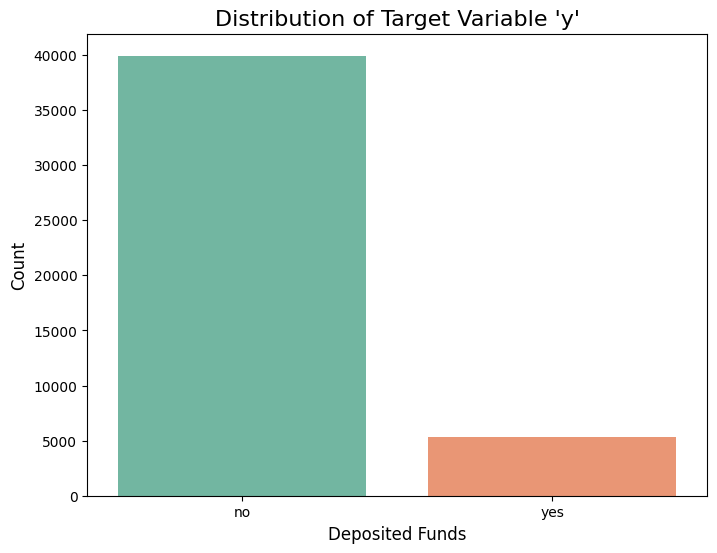

In [14]:
plt.figure(figsize=(8,6))
sns.countplot(x='y', data=df, palette='Set2')
plt.title("Distribution of Target Variable 'y'", fontsize=16)
plt.xlabel("Deposited Funds", fontsize=12)
plt.ylabel('Count', fontsize=12)

print ((df['y'].value_counts(normalize=True) * 100).round(0))

# Conversion and Encoding Ready for the MLP

In [15]:
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['job', 'marital', 'education', 'contact', 'poutcome']

# Binary columns that should not be one-hot encoded
binary_columns = ['default', 'housing', 'loan', 'y']

# Columns to exclude from the system
excluded_features = ['duration','campaign','pdays','previous']
df.drop(columns=excluded_features, inplace=True)



In [16]:
# Encode the Binary Features
for col in binary_columns:
    # Convert yes/no outcome to float versions
    df[col] = df[col].map({'yes': 1.0, 'no': 0.0}).astype(float)

# One Hot Encode the categorical features
df_one_hot = pd.get_dummies(df)

In [17]:
df_one_hot.sample(10)

,age,default,balance,housing,loan,day,y,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
15320,33,0.0,3269,0.0,1.0,18,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
27832,41,0.0,102,0.0,0.0,28,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
11122,36,0.0,8267,0.0,0.0,18,0.0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
8647,39,0.0,548,1.0,0.0,3,0.0,True,False,False,...,True,False,False,False,False,False,False,False,False,True
39256,48,0.0,5306,1.0,0.0,18,0.0,False,True,False,...,False,False,True,False,False,False,True,False,False,False
41953,38,0.0,4174,0.0,0.0,23,1.0,False,False,False,...,False,False,False,False,True,False,True,False,False,False
35950,31,0.0,11,1.0,0.0,8,0.0,False,False,False,...,False,False,True,False,False,False,False,False,False,True
27427,47,0.0,0,1.0,0.0,21,0.0,True,False,False,...,False,False,False,True,False,False,True,False,False,False
32812,49,0.0,29,1.0,0.0,17,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
23047,41,0.0,231,0.0,0.0,26,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [18]:
# Reencode the True/False values as floats (True = 1.0, False = 0.0)
df_one_hot = df_one_hot.astype(float)
df_one_hot.sample(10)

,age,default,balance,housing,loan,day,y,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
8000,40.0,0.0,2378.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
15769,31.0,0.0,1890.0,1.0,0.0,21.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5298,31.0,0.0,5889.0,1.0,0.0,23.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24030,38.0,0.0,0.0,0.0,0.0,29.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12699,39.0,0.0,551.0,0.0,1.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19990,47.0,0.0,131.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9505,41.0,0.0,762.0,1.0,0.0,6.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
17238,28.0,0.0,181.0,1.0,0.0,28.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24929,37.0,0.0,1205.0,1.0,0.0,18.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
21638,36.0,0.0,71.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Define Normalisation and Label Encoding Functions

The goal is that all features contribute roughly equally to the training of the neural network.

$ x_scaled = \frac{x - min(x)}{max(x)-min(x)}$



In [19]:
def max_min_normalize (df, column_name):
    max_value = df[column_name].max()
    min_value = df[column_name].min()
    df[column_name] = (df[column_name] - min_value) / (max_value - min_value)
    return df

# Unused below here... initially?

def label_encode(df, column_name):
    # Get unique values in the column
    unique_values = df[column_name].unique()
    
    # Create a mapping of unique values to integers
    mapping = {value: i for i, value in enumerate(unique_values)}
    
    # Apply the mapping to the column
    df[column_name] = df[column_name].map(mapping).astype(float)
    return df

def encode_binary (df, column_name):
    df[column_name] = df[column_name].map({'yes': 1.0, 'no': 0.0}).astype(float)
    return df


In [20]:
# Scale each column, one at a time
for col in df_one_hot.columns.to_list():
    df_scaled = max_min_normalize(df_one_hot, col)

In [21]:

df_scaled.sample(10)

,age,default,balance,housing,loan,day,y,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
20643,0.285714,0.0,0.112714,0.0,0.0,0.366667,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
34919,0.415584,1.0,0.094638,1.0,0.0,0.166667,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9558,0.246753,0.0,0.086867,0.0,0.0,0.166667,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7162,0.389610,0.0,0.090144,1.0,0.0,0.933333,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19163,0.272727,0.0,0.147205,0.0,0.0,0.133333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
32842,0.311688,0.0,0.075654,1.0,1.0,0.533333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10179,0.480519,0.0,0.153551,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
39129,0.207792,0.0,0.111425,1.0,0.0,0.566667,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
43358,0.103896,0.0,0.152243,0.0,0.0,0.833333,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2658,0.285714,0.0,0.073648,1.0,0.0,0.400000,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Write out these arrays to files

In [22]:
# Create filenames, one timestamped, one 'latest'
filepath = "."

filename = f'{filepath}/bank_full_scaled_{now_date_timestamp}.csv'
latest_filename = f'{filepath}/bank_full_scaled_latest.csv'

# Write out CSV files
df_scaled.to_csv(filename, index=False)
df_scaled.to_csv(latest_filename, index=False)